- 그냥 해보기
- L1 규제로 진행 (규제값 알아서 해보고) → 나중에 1~2개로 통일
- 엘라스틱 규제로 진행
- optuna 사용해서 하이퍼파라미터 최적화 해서 해보기

In [16]:
import pandas as pd
import numpy as np

_ROOT_DIR = "./../../../"

# 데이터 load

In [17]:
df = pd.read_csv(_ROOT_DIR+"./data/preprocessed/cell2cell_train.csv")
target = pd.read_csv(_ROOT_DIR+"./data/preprocessed/cell2cell_train_churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49776 entries, 0 to 49775
Data columns (total 65 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MonthlyRevenue             49776 non-null  float64
 1   MonthlyMinutes             49776 non-null  float64
 2   TotalRecurringCharge       49776 non-null  float64
 3   DirectorAssistedCalls      49776 non-null  float64
 4   OverageMinutes             49776 non-null  float64
 5   RoamingCalls               49776 non-null  float64
 6   PercChangeMinutes          49776 non-null  float64
 7   PercChangeRevenues         49776 non-null  float64
 8   DroppedCalls               49776 non-null  float64
 9   BlockedCalls               49776 non-null  float64
 10  UnansweredCalls            49776 non-null  float64
 11  CustomerCareCalls          49776 non-null  float64
 12  ThreewayCalls              49776 non-null  float64
 13  ReceivedCalls              49776 non-null  flo

In [18]:
drop_cols = [
    'ThreewayCalls',
    'DroppedCalls',
    'CallForwardingCalls',
'CallWaitingCalls',
    'ActiveSubs',
    'TruckOwner',
'RVOwner',
'BuysViaMailOrder',
    'RetentionOffersAccepted',
    'NewCellphoneUser',
'NotNewCellphoneUser',
'ReferralsMadeBySubscriber',
'OwnsMotorcycle',
'AdjustmentsToCreditRating',
]
filtered_cols1 = df.filter(like='Occ_').columns
filtered_cols2 = df.filter(like='Prizm_').columns
df = df.drop(drop_cols, axis=1)
df = df.drop(filtered_cols1, axis=1)
df = df.drop(filtered_cols2, axis=1)

In [19]:
target_cols = [
'CurrentEquipmentDays',
'MonthsInService',
'MonthlyMinutes',
'PercChangeMinutes',
'PercChangeRevenues',
'TotalRecurringCharge',
'AgeHH1',
'MonthlyRevenue',
'CreditRating',
'OverageMinutes',
'HandsetRefurbished',
'IncomeGroup',
'UniqueSubs',
'HandsetPrice',
'PeakCallsInOut',
'DroppedBlockedCalls',
'RoamingCalls',
'HandsetWebCapable',
'UnansweredCalls',
'BlockedCalls',

]
df = df[target_cols]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49776 entries, 0 to 49775
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CurrentEquipmentDays  49776 non-null  float64
 1   MonthsInService       49776 non-null  float64
 2   MonthlyMinutes        49776 non-null  float64
 3   PercChangeMinutes     49776 non-null  float64
 4   PercChangeRevenues    49776 non-null  float64
 5   TotalRecurringCharge  49776 non-null  float64
 6   AgeHH1                49776 non-null  float64
 7   MonthlyRevenue        49776 non-null  float64
 8   CreditRating          49776 non-null  int64  
 9   OverageMinutes        49776 non-null  float64
 10  HandsetRefurbished    49776 non-null  int64  
 11  IncomeGroup           49776 non-null  float64
 12  UniqueSubs            49776 non-null  float64
 13  HandsetPrice          49776 non-null  float64
 14  PeakCallsInOut        49776 non-null  float64
 15  DroppedBlockedCalls

In [20]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(df, target, test_size=0.2, random_state=42)
print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

(39820, 20) (9956, 20) (39820, 1) (9956, 1)


# 기본 학습

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(xtrain, ytrain)
rf.score(xtest, ytest)


c:\Users\Playdata\AppData\Local\miniconda3\envs\mlstudy_env\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.7184612294094014

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
ypred = rf.predict(xtest)
print(accuracy_score(ypred, ytest))
print(rf.score(xtest, ytest))

0.7184612294094014
0.7184612294094014


In [39]:
rf.feature_importances_

array([0.14533457, 0.12433346, 0.09705738, 0.09058989, 0.06038413,
       0.05228814, 0.04118362, 0.05746699, 0.02759537, 0.03881654,
       0.01273093, 0.02441704, 0.01301258, 0.0139883 , 0.05416465,
       0.04258575, 0.02017131, 0.00992989, 0.04463147, 0.02931798])

In [40]:
xtrain.columns

Index(['CurrentEquipmentDays', 'MonthsInService', 'MonthlyMinutes',
       'PercChangeMinutes', 'PercChangeRevenues', 'TotalRecurringCharge',
       'AgeHH1', 'MonthlyRevenue', 'CreditRating', 'OverageMinutes',
       'HandsetRefurbished', 'IncomeGroup', 'UniqueSubs', 'HandsetPrice',
       'PeakCallsInOut', 'DroppedBlockedCalls', 'RoamingCalls',
       'HandsetWebCapable', 'UnansweredCalls', 'BlockedCalls'],
      dtype='object')

CurrentEquipmentDays    0.090798
MonthlyMinutes          0.084511
PercChangeMinutes       0.083866
MonthlyRevenue          0.074582
PercChangeRevenues      0.072654
PeakCallsInOut          0.068890
UnansweredCalls         0.065520
MonthsInService         0.063140
DroppedBlockedCalls     0.058156
TotalRecurringCharge    0.049206
AgeHH1                  0.048123
BlockedCalls            0.045119
OverageMinutes          0.044197
IncomeGroup             0.036698
RoamingCalls            0.030580
CreditRating            0.028385
HandsetPrice            0.021822
UniqueSubs              0.019668
HandsetRefurbished      0.008198
HandsetWebCapable       0.005887
dtype: float64


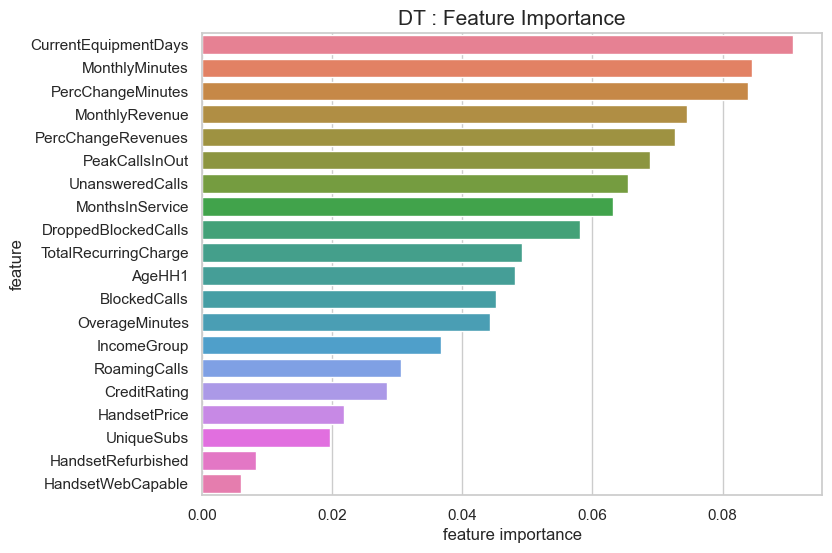

In [23]:
import seaborn as sns
from matplotlib import pyplot as plt

# 특성 중요도
fesat_impt_ser = pd.Series(rf.feature_importances_, index=xtrain.columns)
fesat_impt_ser = fesat_impt_ser.sort_values(ascending=False)
fesat_impt_ser = fesat_impt_ser.head(20)
print(fesat_impt_ser)
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('DT : Feature Importance', fontsize=15)

plt.show()

In [42]:
# Confusion graph
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
ypred = rf.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.72      0.99      0.83      7112
           1       0.62      0.05      0.09      2844

    accuracy                           0.72      9956
   macro avg       0.67      0.52      0.46      9956
weighted avg       0.69      0.72      0.62      9956



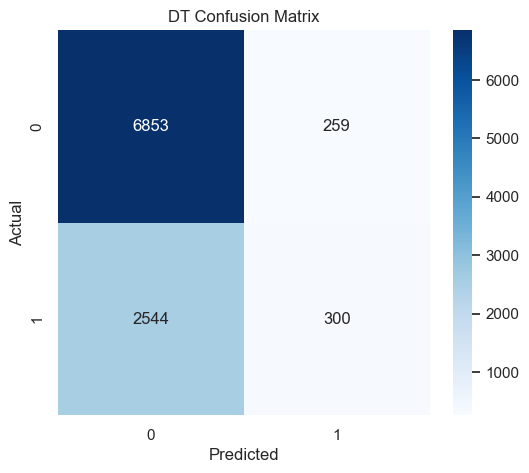

In [25]:
# Confusion Matrix 시각화2
cm = confusion_matrix(ytest, ypred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.figure(figsize=(6,5))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RF Confusion Matrix')

# plt.savefig('./graphs/RF_balanced_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

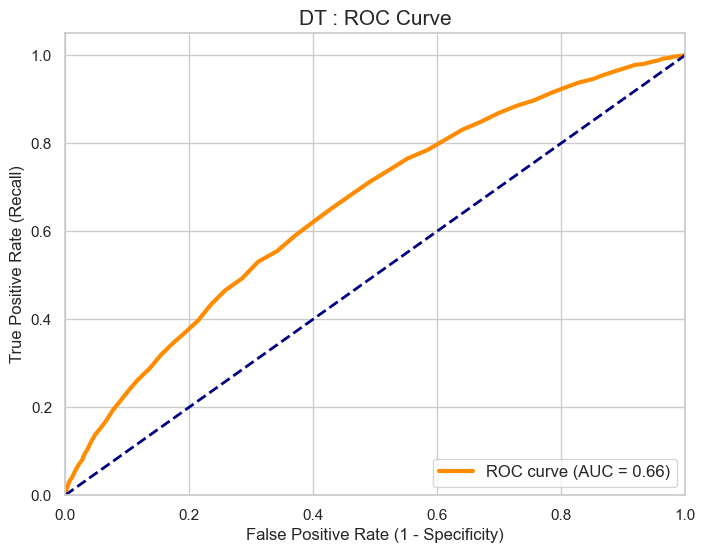

0.6553269547793867


In [26]:
# ROC 그래프
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(ytest, rf.predict_proba(xtest)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('RF : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

# plt.savefig('./graphs/RF_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)

---
---

# 최적화 적용

In [27]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
## optuna
def objective(trial):
    # 하이퍼파라미터 탐색 범위 설정
    params = {
        # 나무의 개수: 100~500개 범위에서 탐색
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        # 나무의 깊이: 너무 깊으면 과적합되므로 5~30 범위
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        # 노드 분할 최소 샘플: 20~500 사이
        'min_samples_split': trial.suggest_int('min_samples_split', 20, 500),
        # 리프 노드 최소 샘플
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 200),
        # 나무가 고려할 최대 특성 개수
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    # 모델 생성 및 교차 검증
    rf = RandomForestClassifier(**params, n_jobs=-1, random_state=42)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(rf, xtrain, ytrain, cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# 4. 결과 확인
print("-" * 30)
print(f"최적의 파라미터: {study.best_params}")
print(f"최고 정확도: {study.best_value:.4f}")

[I 2026-02-23 14:38:50,145] A new study created in memory with name: no-name-61fafbec-e3bf-4b84-816e-d26fa1c458b2


[I 2026-02-23 14:39:00,183] Trial 0 finished with value: 0.6620630466400851 and parameters: {'n_estimators': 431, 'max_depth': 8, 'min_samples_split': 215, 'min_samples_leaf': 20, 'max_features': 'log2'}. Best is trial 0 with value: 0.6620630466400851.
[I 2026-02-23 14:39:11,157] Trial 1 finished with value: 0.6661981963575906 and parameters: {'n_estimators': 476, 'max_depth': 17, 'min_samples_split': 152, 'min_samples_leaf': 72, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.6661981963575906.
[I 2026-02-23 14:39:17,362] Trial 2 finished with value: 0.6664188962815243 and parameters: {'n_estimators': 191, 'max_depth': 11, 'min_samples_split': 75, 'min_samples_leaf': 45, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.6664188962815243.
[I 2026-02-23 14:39:24,831] Trial 3 finished with value: 0.6593642522542147 and parameters: {'n_estimators': 329, 'max_depth': 14, 'min_samples_split': 66, 'min_samples_leaf': 191, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.6664

------------------------------
최적의 파라미터: {'n_estimators': 252, 'max_depth': 24, 'min_samples_split': 102, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
최고 정확도: 0.6708


In [28]:
from sklearn.ensemble import RandomForestClassifier
# rf = DecisionTreeClassifier()
rf = RandomForestClassifier(n_estimators= 230, max_depth= 15, min_samples_split= 60, min_samples_leaf= 23, max_features= 'log2')
rf.fit(xtrain, ytrain)
rf.score(xtest, ytest) 
# 최적화 전: 0.7162515066291684
# 최적화 후: 0.7194656488549618


c:\Users\Playdata\AppData\Local\miniconda3\envs\mlstudy_env\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.7194656488549618

CurrentEquipmentDays    0.145335
MonthsInService         0.124333
MonthlyMinutes          0.097057
PercChangeMinutes       0.090590
PercChangeRevenues      0.060384
MonthlyRevenue          0.057467
PeakCallsInOut          0.054165
TotalRecurringCharge    0.052288
UnansweredCalls         0.044631
DroppedBlockedCalls     0.042586
AgeHH1                  0.041184
OverageMinutes          0.038817
BlockedCalls            0.029318
CreditRating            0.027595
IncomeGroup             0.024417
RoamingCalls            0.020171
HandsetPrice            0.013988
UniqueSubs              0.013013
HandsetRefurbished      0.012731
HandsetWebCapable       0.009930
dtype: float64


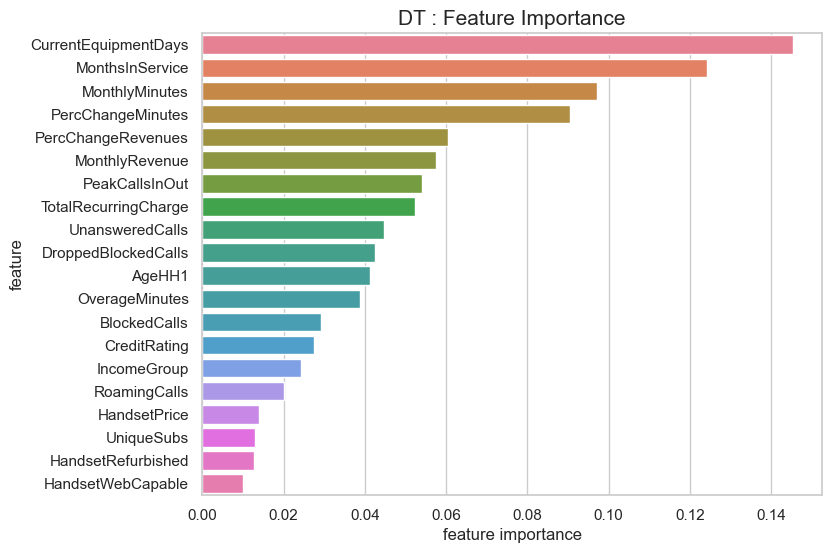

In [29]:
import seaborn as sns
from matplotlib import pyplot as plt

# 특성 중요도
fesat_impt_ser = pd.Series(rf.feature_importances_, index=xtrain.columns)
fesat_impt_ser = fesat_impt_ser.sort_values(ascending=False)
fesat_impt_ser = fesat_impt_ser.head(20)
print(fesat_impt_ser)
plt.figure(figsize=(8,6))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('DT : Feature Importance', fontsize=15)

plt.show()

In [30]:
# Confusion graph
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
ypred = rf.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.72      0.99      0.83      7112
           1       0.62      0.05      0.09      2844

    accuracy                           0.72      9956
   macro avg       0.67      0.52      0.46      9956
weighted avg       0.69      0.72      0.62      9956



In [31]:
# Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
ypred = rf.predict(xtest)
print("              DT Classification Report")
print(classification_report(ytest, ypred))

              DT Classification Report
              precision    recall  f1-score   support

           0       0.72      0.99      0.83      7112
           1       0.62      0.05      0.09      2844

    accuracy                           0.72      9956
   macro avg       0.67      0.52      0.46      9956
weighted avg       0.69      0.72      0.62      9956



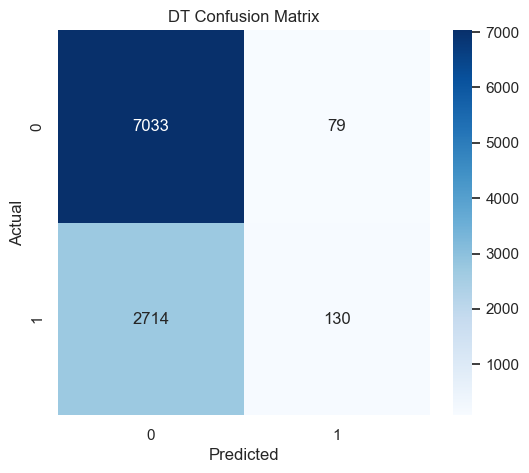

In [32]:
# Confusion Matrix 시각화2
cm = confusion_matrix(ytest, ypred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DT Confusion Matrix')

# plt.savefig('./graphs/DT_balanced_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

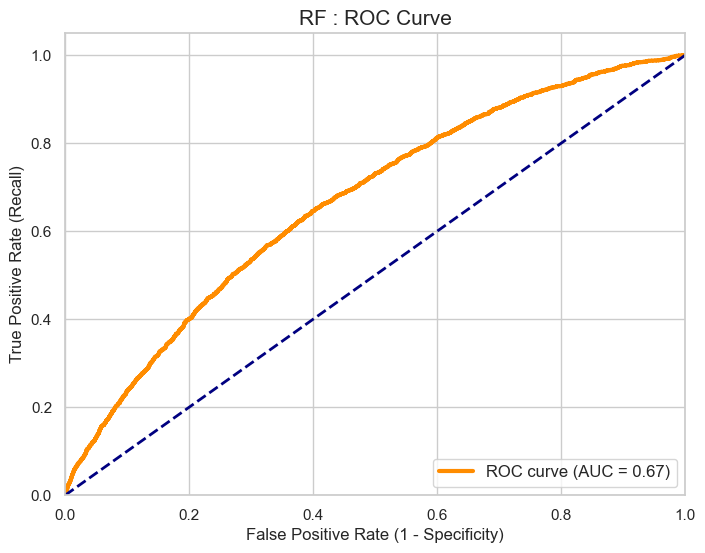

0.6666220717663457


In [43]:
# ROC 그래프
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(ytest, rf.predict_proba(xtest)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('RF : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

# plt.savefig('./graphs/DT_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)

In [44]:
import joblib
joblib.dump(rf, './model_rf.pkl')

['./model_rf.pkl']